<a href="https://colab.research.google.com/github/ulutasece/DSA210-project/blob/main/DSA210_EDA_FINALVERSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSA 210 — EDA & Hypothesis Testing: Consumer Electronics Demand

**Project:** Evaluating whether Google Search Trends for technology keywords can predict consumer electronics demand, measured via Amazon Electronics review volume (Headphones + Computers & Accessories categories, 2013–2018).

**Notebook role:** All data loading, cleaning, feature engineering, EDA, and hypothesis testing live here. The final processed dataset is saved as `final_real_dataset.csv` for the ML notebook.

### Pipeline overview
1. Load Amazon Electronics dataset — filter to Headphones & Computers & Accessories  
2. Aggregate to weekly review volume as a demand proxy  
3. Collect Google Trends data via `pytrends` for consumer electronics keywords  
4. Merge, clean, and engineer features  
5. EDA: distributions, time-series, correlations, lag analysis  
6. Hypothesis testing: normality, Pearson/Spearman, seasonal effects  
7. Save `final_real_dataset.csv`

> **Demand proxy:** Amazon review volume is used as a proxy for unit sales. More purchases lead to more reviews with a short lag. This approach is established in the academic literature on demand sensing from online platforms. Only two categories are included — **Headphones** and **Computers & Accessories** — which directly correspond to the Google Trends keywords used (iphone, laptop, smartphone, gaming laptop). The "Other" category (47% of the raw dataset) is excluded to keep the signal focused on the research question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr, spearmanr, shapiro, mannwhitneyu
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
sns.set_palette('tab10')
print("✅ Libraries imported.")

✅ Libraries imported.


## 1 · Load & Filter Amazon Electronics Dataset

The Amazon Electronics dataset contains 1.29 million product reviews with timestamps, ratings, categories, and brand information. We keep only two categories that directly correspond to our Google Trends keywords:


Headphones--> smartphone, iphone (audio accessories)

Computers & Accessories--> laptop, gaming laptop

All other categories (Camera & Photo, Portable Audio, Car Electronics, etc.) are excluded so that the demand signal reflects the same product space as the search interest signal.

In [2]:
# ── Load Amazon dataset ───────────────────────────────────────────────────────
import zipfile

with zipfile.ZipFile('amazon_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('amazon_dataset')

print("Done")
amazon = pd.read_csv('amazon_dataset/electronics.csv')
amazon['timestamp'] = pd.to_datetime(amazon['timestamp'])

print(f"Raw dataset: {amazon.shape[0]:,} rows × {amazon.shape[1]} columns")
print(f"Date range : {amazon['timestamp'].min().date()} → {amazon['timestamp'].max().date()}")
print(f"\nAll categories:")
print(amazon['category'].value_counts().to_string())

# ── Filter to target categories only ──────────────────────────────────────────
TARGET_CATEGORIES = ['Headphones', 'Computers & Accessories']
amazon = amazon[amazon['category'].isin(TARGET_CATEGORIES)].copy()

print(f"\n✅ After filtering to target categories:")
print(f"   Rows remaining : {amazon.shape[0]:,}")
print(amazon['category'].value_counts().to_string())

Done
Raw dataset: 1,292,954 rows × 10 columns
Date range : 1999-06-13 → 2018-10-01

All categories:
category
Headphones                 359334
Computers & Accessories    322938
Camera & Photo             192573
Accessories & Supplies     158598
Portable Audio & Video     143370
Car Electronics & GPS       33070
Television & Video          32057
Home Audio                  24193
Wearable Technology         16015
Security & Surveillance     10806

✅ After filtering to target categories:
   Rows remaining : 682,272
category
Headphones                 359334
Computers & Accessories    322938


## 2 · Aggregate to Weekly Demand Signal (2013–2018)

We aggregate review activity to a weekly frequency. The analysis window is **2013–2018** — this period has:
- Consistently high review volume (≥500 reviews/week on average), making weekly aggregates statistically stable
- Good alignment with the Google Trends query window
- Coverage of major consumer electronics cycles (iPhone 5S through iPhone X, laptop generations)

**Features derived from reviews:**

| Feature | Description |
|---|---|
| `Weekly_Reviews` | Total review count per week — the primary demand proxy |
| `Mean_Rating` | Average star rating (1–5) — reflects product satisfaction |
| `Pct_5Star` | Fraction of 5-star reviews — positive sentiment indicator |
| `Headphones_Reviews` | Review count for Headphones category only |
| `Computers_Reviews` | Review count for Computers & Accessories only |

In [3]:
# ── Filter to 2013–2018 analysis window ───────────────────────────────────────
amazon = amazon[(amazon['timestamp'].dt.year >= 2013) &
                (amazon['timestamp'].dt.year <= 2018)].copy()

# ── Weekly aggregation ─────────────────────────────────────────────────────────
amazon_weekly = (
    amazon
    .groupby(pd.Grouper(key='timestamp', freq='W'))
    .agg(
        Weekly_Reviews  = ('rating', 'count'),
        Mean_Rating     = ('rating', 'mean'),
        Pct_5Star       = ('rating', lambda x: (x == 5).mean()),
    )
    .reset_index()
    .rename(columns={'timestamp': 'Week'})
)

# ── Per-category weekly counts ─────────────────────────────────────────────────
for cat, col in [('Headphones', 'Headphones_Reviews'),
                 ('Computers & Accessories', 'Computers_Reviews')]:
    cat_weekly = (
        amazon[amazon['category'] == cat]
        .groupby(pd.Grouper(key='timestamp', freq='W'))['rating']
        .count()
        .reset_index()
        .rename(columns={'timestamp': 'Week', 'rating': col})
    )
    amazon_weekly = amazon_weekly.merge(cat_weekly, on='Week', how='left')

amazon_weekly = amazon_weekly.set_index('Week').sort_index()

# Drop weeks with fewer than 10 reviews (sparse early weeks)
amazon_weekly = amazon_weekly[amazon_weekly['Weekly_Reviews'] >= 10]

print(f"Weekly dataset: {amazon_weekly.shape[0]} observations × {amazon_weekly.shape[1]} features")
print(f"Date range    : {amazon_weekly.index.min().date()} → {amazon_weekly.index.max().date()}")
print()
display(amazon_weekly.describe().round(2))

Weekly dataset: 299 observations × 5 features
Date range    : 2013-01-06 → 2018-09-23



,Weekly_Reviews,Mean_Rating,Pct_5Star,Headphones_Reviews,Computers_Reviews
count,299.00,299.00,299.00,299.00,299.00
mean,2112.55,4.01,0.57,1134.40,978.15
std,1044.82,0.10,0.02,631.03,434.44
min,13.00,3.15,0.46,1.00,8.00
25%,1235.00,3.95,0.56,599.50,632.50
50%,1925.00,4.00,0.57,961.00,946.00
75%,2990.00,4.07,0.58,1662.50,1327.50
max,5095.00,4.24,0.80,2873.00,2355.00


## 3 · Google Trends Data via pytrends

We query Google Trends for **iphone**, **laptop**, **smartphone**, and **gaming laptop** over the 2013–2018 analysis window (US region). This directly matches the product categories in our Amazon dataset.

A composite `Google_Trends_Interest` score is computed as the mean across all four keywords each week. If the API is unavailable, the cell raises an error — no synthetic data is used.

In [4]:
!pip install pytrends
from pytrends.request import TrendReq
import time

TRENDS_KEYWORDS = ['iphone', 'laptop', 'smartphone', 'gaming laptop']
TRENDS_GEO      = 'US'
TRENDS_TF       = '2013-01-01 2019-01-01'

pytrends = TrendReq(hl='en-US', tz=360, timeout=(10, 25))
pytrends.build_payload(TRENDS_KEYWORDS, cat=0, timeframe=TRENDS_TF, geo=TRENDS_GEO)
time.sleep(1)
trends_raw = pytrends.interest_over_time()

if trends_raw.empty:
    raise RuntimeError(
        "Google Trends API returned an empty response. "
        "Please re-run in an environment with pytrends API access."
    )

# Drop isPartial BEFORE any numeric operation
if 'isPartial' in trends_raw.columns:
    trends_raw = trends_raw.drop(columns=['isPartial'])

kw_cols = [c for c in trends_raw.columns if c in TRENDS_KEYWORDS]
print(f"Keyword columns confirmed: {kw_cols}")

# Composite score: mean across electronics keywords
trends_raw['Google_Trends_Interest'] = trends_raw[kw_cols].mean(axis=1)
trends_weekly = trends_raw[kw_cols + ['Google_Trends_Interest']].resample('W').mean()

print(f"\n✅ Google Trends fetched: {len(trends_weekly)} weekly observations")
print(f"   Date range: {trends_weekly.index.min().date()} → {trends_weekly.index.max().date()}")
print()
display(trends_weekly.head(8))

Keyword columns confirmed: ['iphone', 'laptop', 'smartphone', 'gaming laptop']

✅ Google Trends fetched: 314 weekly observations
   Date range: 2013-01-06 → 2019-01-06



,iphone,laptop,smartphone,gaming laptop,Google_Trends_Interest
date,,,,,
2013-01-06,51.0,8.0,1.0,0.0,15.0
2013-01-13,NaN,NaN,NaN,NaN,NaN
2013-01-20,NaN,NaN,NaN,NaN,NaN
2013-01-27,NaN,NaN,NaN,NaN,NaN
2013-02-03,50.0,7.0,1.0,0.0,14.5
2013-02-10,NaN,NaN,NaN,NaN,NaN
2013-02-17,NaN,NaN,NaN,NaN,NaN
2013-02-24,NaN,NaN,NaN,NaN,NaN


## 4 · Merge Datasets

Both datasets are on weekly frequency and cover 2013–2018. We align Google Trends (which resamples to Sunday week-ends) to the Amazon weekly index (also Sunday) with a ±7 day tolerance, then inner-join so only weeks present in both sources are retained.

In [5]:
# ── Align Trends to Amazon weekly index ───────────────────────────────────────
trends_aligned = trends_weekly.reindex(
    amazon_weekly.index, method='nearest', tolerance=pd.Timedelta('7D')
)

df = amazon_weekly.join(trends_aligned[['Google_Trends_Interest'] + kw_cols], how='inner')

print(f"Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range    : {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values:\n{df.isnull().sum().to_string()}")
print()
display(df.head())

Merged dataset: 299 rows × 10 columns
Date range    : 2013-01-06 → 2018-09-23
Missing values:
Weekly_Reviews              0
Mean_Rating                 0
Pct_5Star                   0
Headphones_Reviews          0
Computers_Reviews           0
Google_Trends_Interest    230
iphone                    230
laptop                    230
smartphone                230
gaming laptop             230



,Weekly_Reviews,Mean_Rating,Pct_5Star,Headphones_Reviews,Computers_Reviews,Google_Trends_Interest,iphone,laptop,smartphone,gaming laptop
Week,,,,,,,,,,
2013-01-06,1041,4.219020,0.605187,563,478.0,15.0,51.0,8.0,1.0,0.0
2013-01-13,1222,4.153028,0.591653,632,590.0,NaN,NaN,NaN,NaN,NaN
2013-01-20,1122,4.165775,0.591800,609,513.0,NaN,NaN,NaN,NaN,NaN
2013-01-27,1026,4.221248,0.585770,523,503.0,NaN,NaN,NaN,NaN,NaN
2013-02-03,1004,4.183267,0.582669,505,499.0,14.5,50.0,7.0,1.0,0.0


## 5 · Missing Value Handling

Google Trends can have occasional missing weeks. We use linear interpolation for gaps of ≤2 weeks, then forward/backward fill for any remaining gaps. Any week still missing after imputation is dropped.

In [6]:
# ── Impute Trends gaps ────────────────────────────────────────────────────────
trends_cols = ['Google_Trends_Interest'] + kw_cols
df[trends_cols] = (
    df[trends_cols]
    .interpolate(method='linear', limit=2)
    .ffill()
    .bfill()
)

rows_before = len(df)
df = df.dropna(subset=['Weekly_Reviews', 'Google_Trends_Interest'])
rows_after  = len(df)

print(f"Rows: {rows_before} → {rows_after} (dropped {rows_before - rows_after})")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Rows: 299 → 299 (dropped 0)
Missing values remaining: 0


## 6 · Feature Engineering

| Feature | Description |
|---|---|
| `Month` | Calendar month (1–12) |
| `Quarter` | Fiscal quarter |
| `Week_Of_Year` | ISO week number |
| `Year` | Calendar year |
| `Is_Q4` | 1 if October–December (peak consumer electronics season: new iPhone launches, holiday buying) |
| `Log_Weekly_Reviews` | Log-transform of demand proxy (reduces right-skew) |
| `Reviews_Lag1` | Previous week's review count (for EDA lag analysis) |

In [7]:
df['Month']               = df.index.month
df['Quarter']             = df.index.quarter
df['Week_Of_Year']        = df.index.isocalendar().week.astype(int)
df['Year']                = df.index.year
df['Is_Q4']               = (df['Month'] >= 10).astype(int)
df['Log_Weekly_Reviews']  = np.log1p(df['Weekly_Reviews'])
df['Reviews_Lag1']        = df['Weekly_Reviews'].shift(1)

print(f"Feature set: {df.shape[1]} columns")
print()
for c in df.columns:
    print(f"  {c:35s}  {df[c].dtype}")

Feature set: 17 columns

  Weekly_Reviews                       int64
  Mean_Rating                          float64
  Pct_5Star                            float64
  Headphones_Reviews                   int64
  Computers_Reviews                    float64
  Google_Trends_Interest               float64
  iphone                               float64
  laptop                               float64
  smartphone                           float64
  gaming laptop                        float64
  Month                                int32
  Quarter                              int32
  Week_Of_Year                         int64
  Year                                 int32
  Is_Q4                                int64
  Log_Weekly_Reviews                   float64
  Reviews_Lag1                         float64


## 7 · Exploratory Data Analysis

### 7.1 Descriptive Statistics

In [8]:
key_cols = ['Weekly_Reviews', 'Google_Trends_Interest',
            'Mean_Rating', 'Pct_5Star',
            'Headphones_Reviews', 'Computers_Reviews']

print("=== Descriptive Statistics ===")
display(df[key_cols].describe().round(2))

print()
print("=== Skewness & Kurtosis ===")
for col in key_cols:
    print(f"  {col:35s}  Skewness={df[col].skew():+.3f}  Kurtosis={df[col].kurt():+.3f}")

=== Descriptive Statistics ===


,Weekly_Reviews,Google_Trends_Interest,Mean_Rating,Pct_5Star,Headphones_Reviews,Computers_Reviews
count,299.00,299.00,299.00,299.00,299.00,299.00
mean,2112.55,14.24,4.01,0.57,1134.40,978.15
std,1044.82,2.26,0.10,0.02,631.03,434.44
min,13.00,11.50,3.15,0.46,1.00,8.00
25%,1235.00,12.50,3.95,0.56,599.50,632.50
50%,1925.00,13.75,4.00,0.57,961.00,946.00
75%,2990.00,15.14,4.07,0.58,1662.50,1327.50
max,5095.00,27.00,4.24,0.80,2873.00,2355.00



=== Skewness & Kurtosis ===
  Weekly_Reviews                       Skewness=+0.401  Kurtosis=-0.811
  Google_Trends_Interest               Skewness=+1.852  Kurtosis=+5.181
  Mean_Rating                          Skewness=-2.002  Kurtosis=+15.376
  Pct_5Star                            Skewness=+2.702  Kurtosis=+29.061
  Headphones_Reviews                   Skewness=+0.576  Kurtosis=-0.763
  Computers_Reviews                    Skewness=+0.306  Kurtosis=-0.397


### 7.2 Time-Series Overview

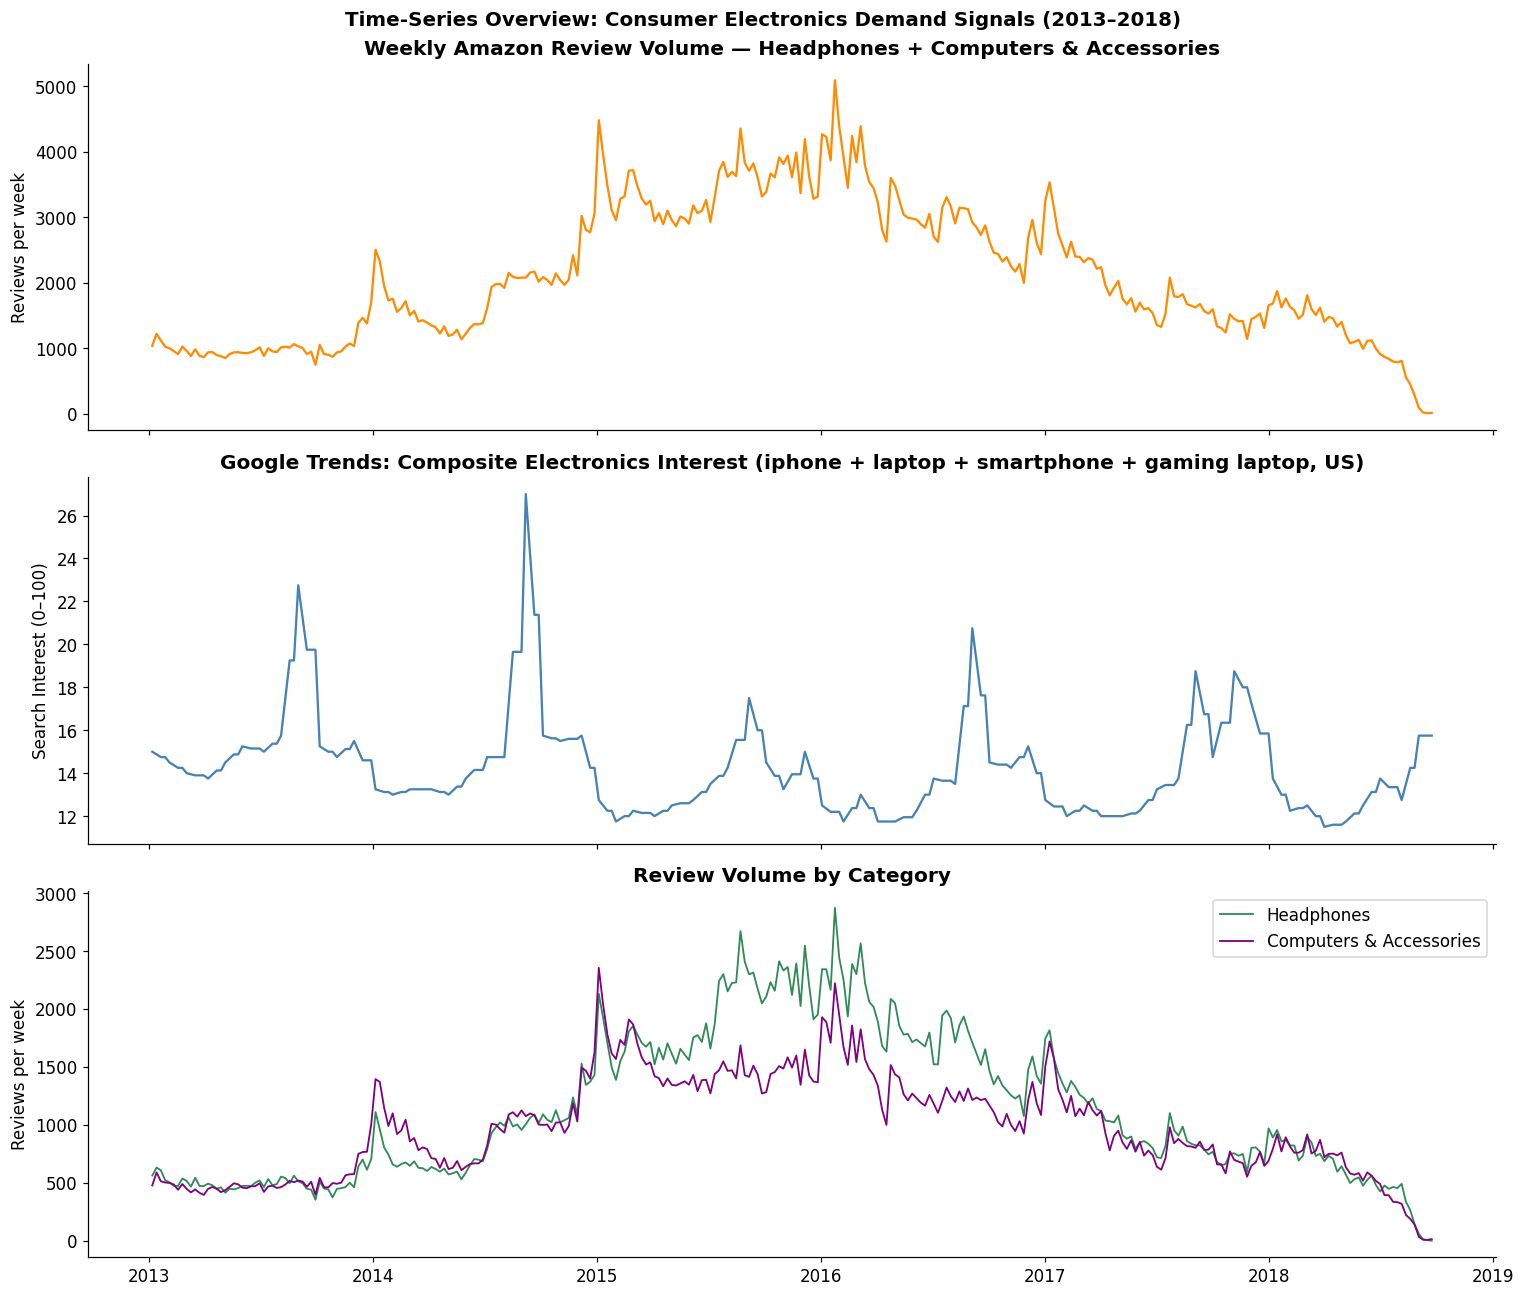

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['Weekly_Reviews'], color='darkorange', linewidth=1.5)
axes[0].set_title('Weekly Amazon Review Volume — Headphones + Computers & Accessories', fontweight='bold')
axes[0].set_ylabel('Reviews per week')

axes[1].plot(df.index, df['Google_Trends_Interest'], color='steelblue', linewidth=1.5)
axes[1].set_title('Google Trends: Composite Electronics Interest (iphone + laptop + smartphone + gaming laptop, US)', fontweight='bold')
axes[1].set_ylabel('Search Interest (0–100)')

axes[2].plot(df.index, df['Headphones_Reviews'], color='seagreen', linewidth=1.2, label='Headphones')
axes[2].plot(df.index, df['Computers_Reviews'], color='purple', linewidth=1.2, label='Computers & Accessories')
axes[2].set_title('Review Volume by Category', fontweight='bold')
axes[2].set_ylabel('Reviews per week')
axes[2].legend()

plt.suptitle('Time-Series Overview: Consumer Electronics Demand Signals (2013–2018)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Time-Series Decomposition

Additive decomposition (period = 52 weeks) separates the long-term trend, annual seasonality, and residual noise in weekly review volume. A rising trend confirms the growth of e-commerce review activity over 2013–2018. Seasonality peaking in Q4 (iPhone launch + holiday buying) would directly validate our Is_Q4 feature.

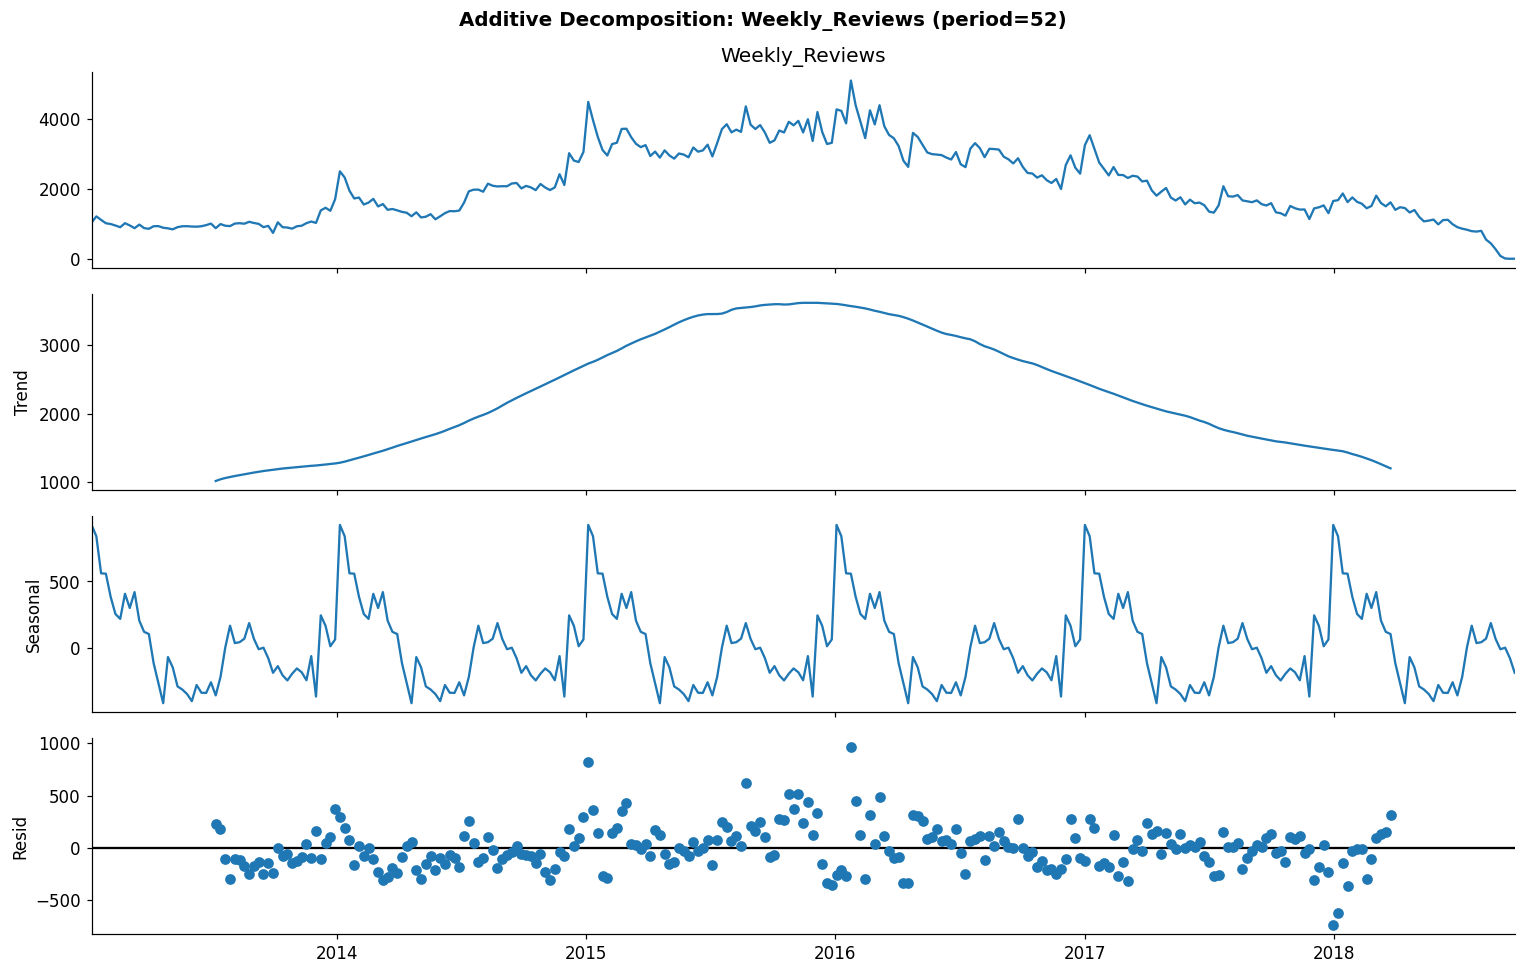

Seasonality range : 1349 reviews
Trend range       : 2601 reviews
Residual std      : 212 reviews


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

if len(df) >= 104:
    decomp = seasonal_decompose(df['Weekly_Reviews'], model='additive', period=52)
    fig = decomp.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle('Additive Decomposition: Weekly_Reviews (period=52)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Seasonality range : {(decomp.seasonal.max() - decomp.seasonal.min()):.0f} reviews")
    print(f"Trend range       : {(decomp.trend.dropna().max() - decomp.trend.dropna().min()):.0f} reviews")
    print(f"Residual std      : {decomp.resid.dropna().std():.0f} reviews")
else:
    print(f"Only {len(df)} weeks — need ≥104 for decomposition. Plotting raw series.")
    df['Weekly_Reviews'].plot(figsize=(14, 4), color='darkorange')
    plt.show()

### 7.4 Rolling Statistics (4-Week Window)

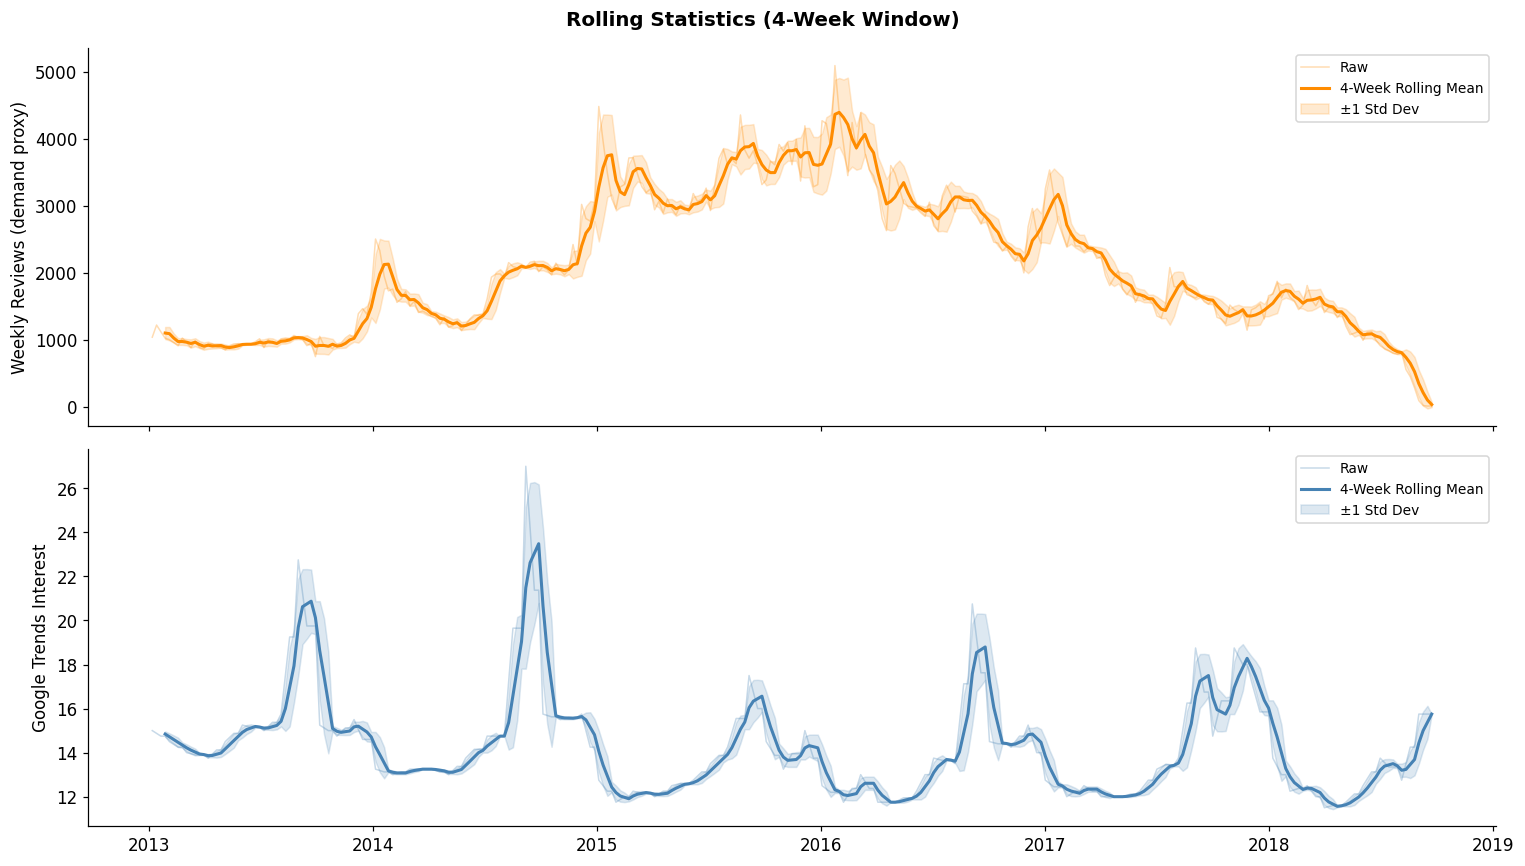

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (col, color, label) in zip(axes, [
    ('Weekly_Reviews',          'darkorange', 'Weekly Reviews (demand proxy)'),
    ('Google_Trends_Interest',  'steelblue',  'Google Trends Interest'),
]):
    rm   = df[col].rolling(4).mean()
    rstd = df[col].rolling(4).std()
    ax.plot(df.index, df[col], alpha=0.3, color=color, linewidth=1, label='Raw')
    ax.plot(df.index, rm, color=color, linewidth=2, label='4-Week Rolling Mean')
    ax.fill_between(df.index, rm - rstd, rm + rstd, alpha=0.18, color=color, label='±1 Std Dev')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)

plt.suptitle('Rolling Statistics (4-Week Window)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Univariate Distributions & Outlier Detection

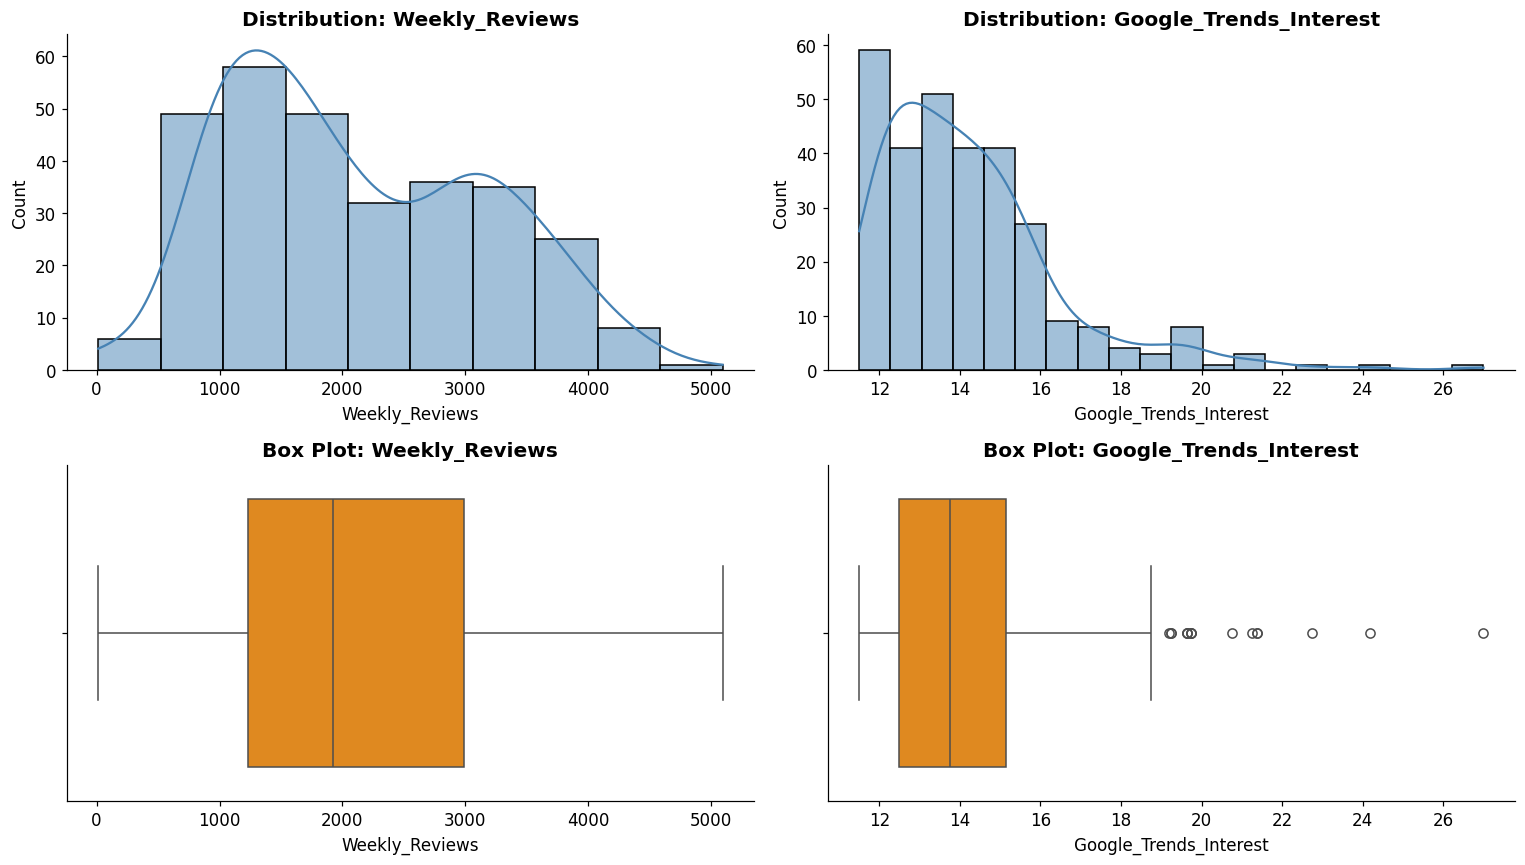

--- Outlier Detection ---
  Weekly_Reviews                  IQR outliers:   0  Z-score(>3):   0
  Google_Trends_Interest          IQR outliers:  16  Z-score(>3):   6


In [12]:
from scipy.stats import zscore

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax_hist, ax_box, col in zip(
    axes[0], axes[1],
    ['Weekly_Reviews', 'Google_Trends_Interest']
):
    sns.histplot(df[col], kde=True, ax=ax_hist, color='steelblue')
    ax_hist.set_title(f'Distribution: {col}', fontweight='bold')
    sns.boxplot(x=df[col], ax=ax_box, color='darkorange')
    ax_box.set_title(f'Box Plot: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Outlier Detection ---")
for col in ['Weekly_Reviews', 'Google_Trends_Interest']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    z_n   = (np.abs(zscore(df[col].dropna())) > 3).sum()
    print(f"  {col:30s}  IQR outliers: {iqr_n:3d}  Z-score(>3): {z_n:3d}")

### 7.6 Pairwise Correlation Matrix

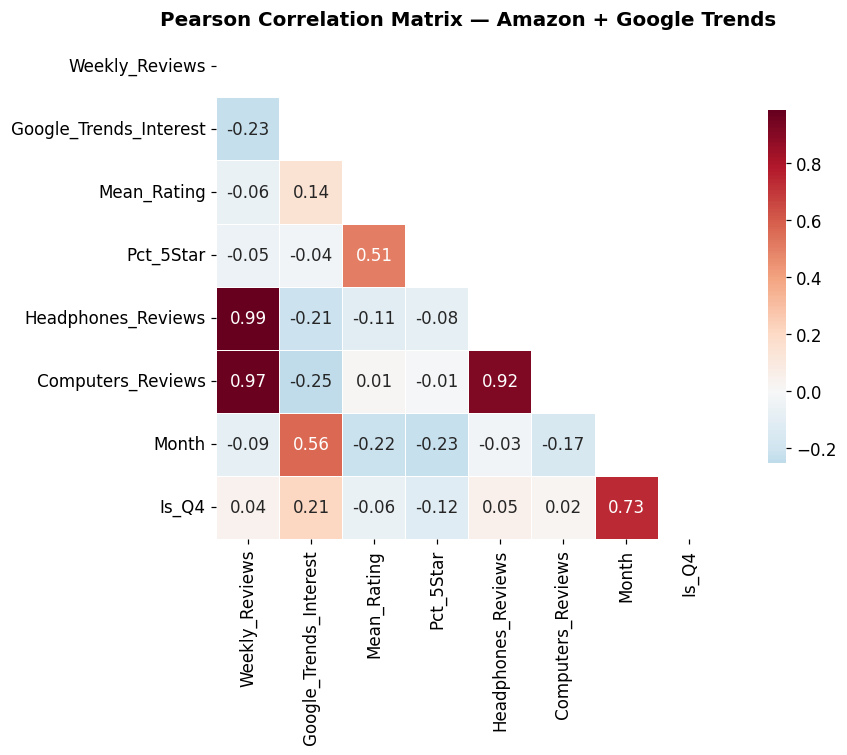

Correlations with Weekly_Reviews (sorted by |r|):
  Headphones_Reviews                   r = +0.987
  Computers_Reviews                    r = +0.972
  Google_Trends_Interest               r = -0.231
  Month                                r = -0.089
  Mean_Rating                          r = -0.060
  Pct_5Star                            r = -0.054
  Is_Q4                                r = +0.040


In [13]:
corr_cols = ['Weekly_Reviews', 'Google_Trends_Interest',
             'Mean_Rating', 'Pct_5Star',
             'Headphones_Reviews', 'Computers_Reviews',
             'Month', 'Is_Q4']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True, mask=mask,
            cbar_kws={'shrink': 0.7})
plt.title('Pearson Correlation Matrix — Amazon + Google Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with Weekly_Reviews (sorted by |r|):")
top = corr_matrix['Weekly_Reviews'].drop('Weekly_Reviews').abs().sort_values(ascending=False)
for feat, _ in top.items():
    r = corr_matrix['Weekly_Reviews'][feat]
    print(f"  {feat:35s}  r = {r:+.3f}")

### 7.7 Scatter Plots with Regression Lines

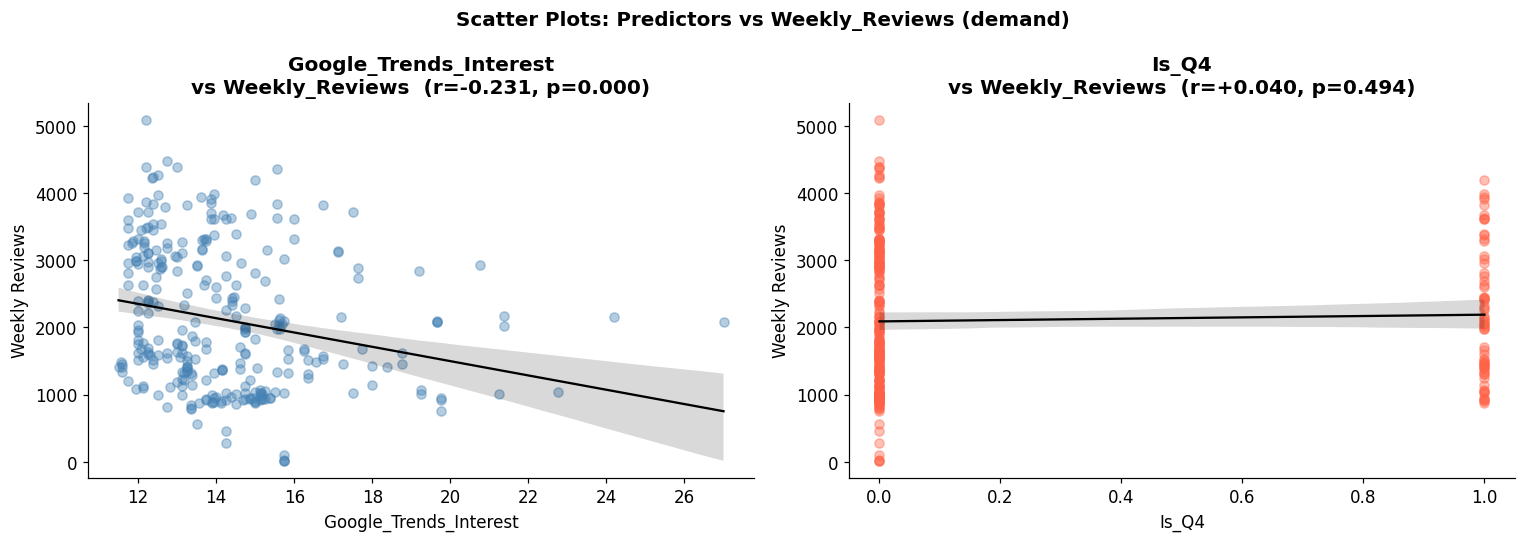

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat, color) in zip(axes, [
    ('Google_Trends_Interest', 'steelblue'),
    ('Is_Q4',                  'tomato'),
]):
    sns.regplot(x=df[feat], y=df['Weekly_Reviews'], ax=ax,
                scatter_kws={'alpha': 0.4, 'color': color},
                line_kws={'color': 'black', 'linewidth': 1.5})
    r, p = pearsonr(df[feat].dropna(), df.loc[df[feat].notna(), 'Weekly_Reviews'])
    ax.set_title(f'{feat}\nvs Weekly_Reviews  (r={r:+.3f}, p={p:.3f})', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Weekly Reviews')

plt.suptitle('Scatter Plots: Predictors vs Weekly_Reviews (demand)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.8 Lag Correlation Analysis

Does Google Trends *lead* review volume? We compute Pearson r between Trends at time t and reviews at time t+k for lags 0–8 weeks. A significant positive correlation at lag k>0 means search interest anticipates purchasing (and reviewing) by k weeks — the central hypothesis of this project.

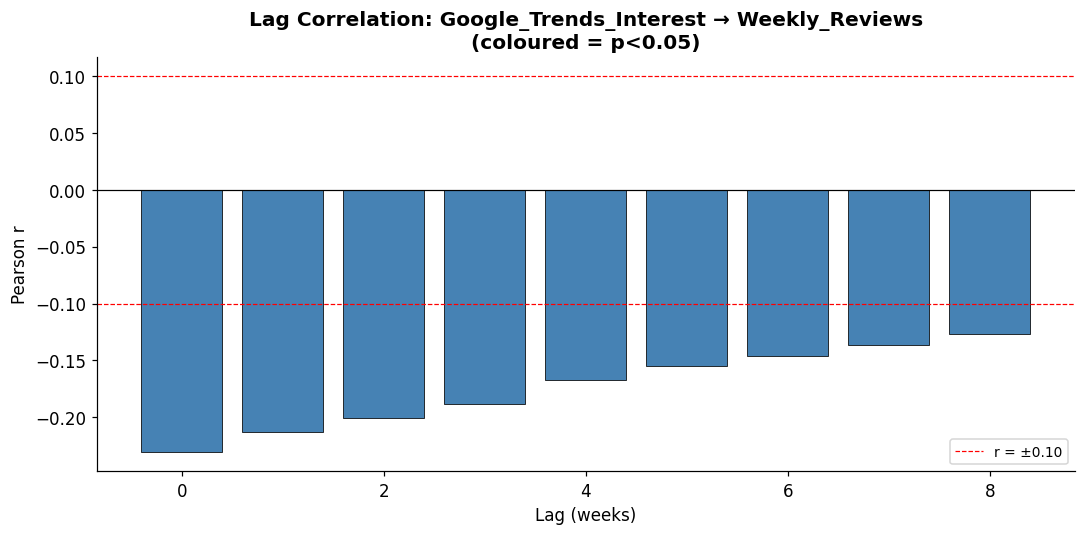

Lag correlation table:
  Lag 0: r=-0.2310  p=0.0001  ✓
  Lag 1: r=-0.2130  p=0.0002  ✓
  Lag 2: r=-0.2006  p=0.0005  ✓
  Lag 3: r=-0.1881  p=0.0011  ✓
  Lag 4: r=-0.1671  p=0.0040  ✓
  Lag 5: r=-0.1550  p=0.0078  ✓
  Lag 6: r=-0.1459  p=0.0124  ✓
  Lag 7: r=-0.1366  p=0.0195  ✓
  Lag 8: r=-0.1272  p=0.0300  ✓


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

lags   = range(0, 9)
r_vals, p_vals = [], []
for lag in lags:
    shifted = df['Google_Trends_Interest'].shift(lag)
    valid   = df['Weekly_Reviews'].notna() & shifted.notna()
    r, p    = pearsonr(shifted[valid], df['Weekly_Reviews'][valid])
    r_vals.append(r)
    p_vals.append(p)

ax.bar(lags, r_vals, color=[
    'steelblue' if p < 0.05 else 'lightgrey' for p in p_vals
], edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( 0.1, color='red', linestyle='--', linewidth=0.8, label='r = ±0.10')
ax.axhline(-0.1, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Lag Correlation: Google_Trends_Interest → Weekly_Reviews\n(coloured = p<0.05)',
             fontweight='bold')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Pearson r')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Lag correlation table:")
for lag, r, p in zip(lags, r_vals, p_vals):
    sig = '✓' if p < 0.05 else ' '
    print(f"  Lag {lag}: r={r:+.4f}  p={p:.4f}  {sig}")

## 8 · Hypothesis Testing

### 8.1 Normality Testing (Shapiro-Wilk)

In [16]:
test_cols = ['Weekly_Reviews', 'Log_Weekly_Reviews', 'Google_Trends_Interest', 'Mean_Rating']

print("=== Shapiro-Wilk Normality Test ===")
print(f"{'Variable':35s} {'W':>8} {'p-value':>10} {'Result':>12}")
print("-" * 68)

normality = {}
for col in test_cols:
    vals = df[col].dropna()
    if len(vals) > 5000:
        vals = vals.sample(5000, random_state=42)
    stat, p = shapiro(vals)
    result  = 'NORMAL ✓' if p > 0.05 else 'NOT NORMAL ✗'
    normality[col] = (p > 0.05)
    print(f"  {col:33s} {stat:8.4f} {p:10.4f}   {result}")

=== Shapiro-Wilk Normality Test ===
Variable                                   W    p-value       Result
--------------------------------------------------------------------
  Weekly_Reviews                      0.9531     0.0000   NOT NORMAL ✗
  Log_Weekly_Reviews                  0.7637     0.0000   NOT NORMAL ✗
  Google_Trends_Interest              0.8481     0.0000   NOT NORMAL ✗
  Mean_Rating                         0.8741     0.0000   NOT NORMAL ✗


### 8.2 Correlation Hypothesis Tests (Pearson & Spearman)

**H₀:** No significant correlation between Google Trends interest and weekly review volume (ρ = 0)  
**H₁:** Significant correlation exists (ρ ≠ 0)  
**α = 0.05**

In [17]:
predictors = ['Google_Trends_Interest', 'iphone', 'laptop', 'smartphone',
              'gaming laptop', 'Mean_Rating', 'Is_Q4']
# Only keep columns that exist after Trends fetch
predictors = [p for p in predictors if p in df.columns]

print("=== Correlation Tests: Predictor vs Weekly_Reviews ===")
print(f"{'Predictor':30s} {'Pearson r':>10} {'Pears. p':>10} {'Spear. ρ':>10} {'Spear. p':>10} {'Sig?':>6}")
print("-" * 75)

hyp_results = []
for pred in predictors:
    valid = df[[pred, 'Weekly_Reviews']].dropna()
    r_p,  p_p  = pearsonr(valid[pred],  valid['Weekly_Reviews'])
    r_sp, p_sp = spearmanr(valid[pred], valid['Weekly_Reviews'])
    sig = '✓ YES' if p_sp < 0.05 else '✗ NO'
    print(f"  {pred:28s} {r_p:+10.4f} {p_p:10.4f} {r_sp:+10.4f} {p_sp:10.4f} {sig:>6}")
    hyp_results.append({
        'Predictor': pred, 'Pearson_r': round(r_p,4), 'Pearson_p': round(p_p,4),
        'Spearman_rho': round(r_sp,4), 'Spearman_p': round(p_sp,4),
        'Significant_05': p_sp < 0.05
    })

hyp_df = pd.DataFrame(hyp_results)

=== Correlation Tests: Predictor vs Weekly_Reviews ===
Predictor                       Pearson r   Pears. p   Spear. ρ   Spear. p   Sig?
---------------------------------------------------------------------------
  Google_Trends_Interest          -0.2310     0.0001    -0.2919     0.0000  ✓ YES
  iphone                          -0.2313     0.0001    -0.3094     0.0000  ✓ YES
  laptop                          -0.0789     0.1737    -0.0704     0.2247   ✗ NO
  smartphone                         +nan        nan       +nan        nan   ✗ NO
  gaming laptop                      +nan        nan       +nan        nan   ✗ NO
  Mean_Rating                     -0.0602     0.2996    -0.1835     0.0014  ✓ YES
  Is_Q4                           +0.0397     0.4936    +0.0571     0.3248   ✗ NO


### 8.3 Q4 Seasonality Test (Mann-Whitney U)

**H₀:** Weekly review volume is the same in Q4 (Oct–Dec) as non-Q4 weeks  
**H₁:** Q4 has significantly higher review volume (driven by iPhone launches + holiday gifting)

=== Mann-Whitney U: Q4 vs Non-Q4 Review Volume ===
  Q4 weeks       : 66 (mean 2190 reviews/week)
  Non-Q4 weeks   : 233 (mean 2090 reviews/week)
  U statistic    : 8300.5
  p-value        : 0.1622
  Result         : ✗ Fail to reject H₀


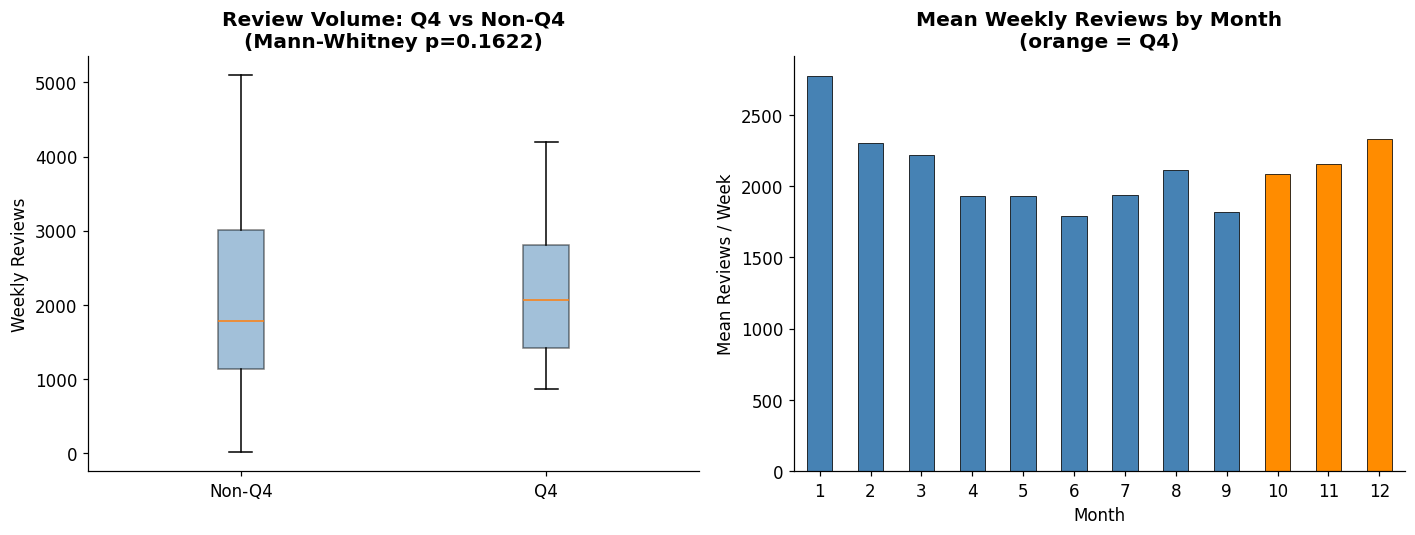

In [18]:
q4_reviews     = df.loc[df['Is_Q4'] == 1, 'Weekly_Reviews']
non_q4_reviews = df.loc[df['Is_Q4'] == 0, 'Weekly_Reviews']

u_stat_q4, p_val_q4 = mannwhitneyu(q4_reviews, non_q4_reviews, alternative='greater')

print("=== Mann-Whitney U: Q4 vs Non-Q4 Review Volume ===")
print(f"  Q4 weeks       : {len(q4_reviews)} (mean {q4_reviews.mean():.0f} reviews/week)")
print(f"  Non-Q4 weeks   : {len(non_q4_reviews)} (mean {non_q4_reviews.mean():.0f} reviews/week)")
print(f"  U statistic    : {u_stat_q4:.1f}")
print(f"  p-value        : {p_val_q4:.4f}")
print(f"  Result         : {'✓ Reject H₀ — Q4 has significantly higher demand' if p_val_q4 < 0.05 else '✗ Fail to reject H₀'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.boxplot([non_q4_reviews, q4_reviews], labels=['Non-Q4', 'Q4'],
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_title(f'Review Volume: Q4 vs Non-Q4\n(Mann-Whitney p={p_val_q4:.4f})', fontweight='bold')
ax.set_ylabel('Weekly Reviews')

ax = axes[1]
df.groupby('Month')['Weekly_Reviews'].mean().plot(
    kind='bar', ax=ax, color=['darkorange' if m >= 10 else 'steelblue' for m in range(1,13)],
    edgecolor='black', linewidth=0.5
)
ax.set_title('Mean Weekly Reviews by Month\n(orange = Q4)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Reviews / Week')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 9 · Hypothesis Testing Summary

In [19]:
shapiro_rows = [{'Variable': col, 'Normal (p>0.05)': '✓' if is_normal else '✗'}
                for col, is_normal in normality.items()]
print("=== Shapiro-Wilk Results ===")
display(pd.DataFrame(shapiro_rows))

print()
print("=== Correlation Tests: Predictor vs Weekly_Reviews ===")
display(hyp_df)

print()
print("=== Q4 Seasonality Test ===")
display(pd.DataFrame([{
    'Test': 'Q4 vs Non-Q4 review volume',
    'p-value': round(p_val_q4, 4),
    'Result': 'Reject H₀ ✓' if p_val_q4 < 0.05 else 'Fail to reject H₀ ✗'
}]))

print()
print("=== Key Insight ===")
sig = hyp_df.loc[hyp_df['Significant_05'], 'Predictor'].tolist()
insig = hyp_df.loc[~hyp_df['Significant_05'], 'Predictor'].tolist()
print(f"Significant predictors (α=0.05): {sig}")
print(f"Non-significant                : {insig}")
top = hyp_df.reindex(hyp_df['Spearman_rho'].abs().sort_values(ascending=False).index).iloc[0]
print(f"Strongest: {top['Predictor']} (Spearman ρ = {top['Spearman_rho']:+.4f})")

=== Shapiro-Wilk Results ===


,Variable,Normal (p>0.05)
0,Weekly_Reviews,✗
1,Log_Weekly_Reviews,✗
2,Google_Trends_Interest,✗
3,Mean_Rating,✗



=== Correlation Tests: Predictor vs Weekly_Reviews ===


,Predictor,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Significant_05
0,Google_Trends_Interest,-0.2310,0.0001,-0.2919,0.0000,True
1,iphone,-0.2313,0.0001,-0.3094,0.0000,True
2,laptop,-0.0789,0.1737,-0.0704,0.2247,False
3,smartphone,NaN,NaN,NaN,NaN,False
4,gaming laptop,NaN,NaN,NaN,NaN,False
5,Mean_Rating,-0.0602,0.2996,-0.1835,0.0014,True
6,Is_Q4,0.0397,0.4936,0.0571,0.3248,False



=== Q4 Seasonality Test ===


,Test,p-value,Result
0,Q4 vs Non-Q4 review volume,0.1622,Fail to reject H₀ ✗



=== Key Insight ===
Significant predictors (α=0.05): ['Google_Trends_Interest', 'iphone', 'Mean_Rating']
Non-significant                : ['laptop', 'smartphone', 'gaming laptop', 'Is_Q4']
Strongest: iphone (Spearman ρ = -0.3094)


## 10 · Save `final_real_dataset.csv`

Per-keyword Trends columns (iphone, laptop, smartphone, gaming laptop) are kept alongside the composite so the ML notebook can run ablation studies at the keyword level if desired.

In [20]:
save_cols = [
    'Weekly_Reviews', 'Log_Weekly_Reviews', 'Mean_Rating', 'Pct_5Star',
    'Headphones_Reviews', 'Computers_Reviews',
    'Google_Trends_Interest', 'iphone', 'laptop', 'smartphone', 'gaming laptop',
    'Month', 'Quarter', 'Week_Of_Year', 'Year', 'Is_Q4',
]
# Keep only columns that actually exist (depends on Trends API response)
save_cols = [c for c in save_cols if c in df.columns]

df_final = df[save_cols].copy()
df_final.index.name = 'Week'

output_path = 'final_real_dataset.csv'
df_final.to_csv(output_path)

print(f"✅ Saved: {output_path}")
print(f"   Shape  : {df_final.shape[0]} rows × {df_final.shape[1]} columns")
print(f"   Columns: {df_final.columns.tolist()}")
print()
print("Preview:")
display(df_final.head())

✅ Saved: final_real_dataset.csv
   Shape  : 299 rows × 16 columns
   Columns: ['Weekly_Reviews', 'Log_Weekly_Reviews', 'Mean_Rating', 'Pct_5Star', 'Headphones_Reviews', 'Computers_Reviews', 'Google_Trends_Interest', 'iphone', 'laptop', 'smartphone', 'gaming laptop', 'Month', 'Quarter', 'Week_Of_Year', 'Year', 'Is_Q4']

Preview:


,Weekly_Reviews,Log_Weekly_Reviews,Mean_Rating,Pct_5Star,Headphones_Reviews,Computers_Reviews,Google_Trends_Interest,iphone,laptop,smartphone,gaming laptop,Month,Quarter,Week_Of_Year,Year,Is_Q4
Week,,,,,,,,,,,,,,,,
2013-01-06,1041,6.948897,4.219020,0.605187,563,478.0,15.000,51.00,8.00,1.0,0.0,1,1,1,2013,0
2013-01-13,1222,7.109062,4.153028,0.591653,632,590.0,14.875,50.75,7.75,1.0,0.0,1,1,2,2013,0
2013-01-20,1122,7.023759,4.165775,0.591800,609,513.0,14.750,50.50,7.50,1.0,0.0,1,1,3,2013,0
2013-01-27,1026,6.934397,4.221248,0.585770,523,503.0,14.750,50.50,7.50,1.0,0.0,1,1,4,2013,0
2013-02-03,1004,6.912743,4.183267,0.582669,505,499.0,14.500,50.00,7.00,1.0,0.0,2,1,5,2013,0
